# Chapter 22: Safe Enough to Act

The most rewarding action is not always one the controller may take. A fast release can have high expected utility while lacking current approval. A different action can be authorized and still exceed a declared risk budget. Those are separate reasons to refuse execution.

This notebook compares three decision boundaries: unconstrained penalty maximization, penalty maximization after authority filtering, and reward maximization after both authority and expected-risk filtering. The example includes explicit abstention. Its purpose is to show what each mathematical formulation permits, rather than treating a large penalty as an invisible substitute for an action prohibition. The changed case relaxes only the expected-risk threshold.

**Outcome:** Compare penalty choice with hard authorization and expected-risk constraints.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later, the complete laboratory folder, and the notebook dependencies listed in `requirements-notebooks.txt` (the launcher's **Install notebook tools** choice installs them; see START-HERE). Standard-library chapter commands also support Python 3.10. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- The mapped chapter and its notation

## The question and its mathematics

Let reward R(a), expected adverse-event probability rho(a), penalty lambda>=0, and current permission A(a) describe an action. Penalty choice maximizes R(a)-lambda rho(a). A finite lambda trades reward against risk; it does not enforce rho(a)<=b or A(a)=true.

Authority filtering forms the set of actions whose permission predicate is true. The constrained choice further requires rho(a)<=b and maximizes reward within that intersection. An empty intersection returns no feasible choice. Abstention appears only if it is explicitly supplied with its own reward, risk, and permission.

An expected-risk limit is a statement about a probability or average, not a pathwise guarantee. A permitted action with rho=0.05 can still realize an adverse event. Similarly, a penalty-optimal action can violate the declared limit when reward is large enough. The method accepts supplied risks; it does not estimate them or prove that a real system's risk is below the given number.

## Apply this to an agent

Apply current authorization before choosing among an agent's actions. Compare a reward penalty with an explicit expected-risk constraint. A finite penalty can still favor an unauthorized choice, and expected risk does not establish safety on every trajectory.

## A calculation you can run

Provide action rows and declare the risk threshold and penalty separately. Validation checks finite rewards, probability domains, and exact permission booleans. The function returns unconstrained penalty choice, authorized penalty choice, constrained choice, and the number of feasible actions. Every alternative remains in the table with its flags and penalized value.

Reward and risk plots use separate vertical units. Compare selected labels with those figures instead of reading a reward bar as safety evidence. Run the default case and identify the first filter that removes each rejected action. In the changed case raise the expected-risk limit to 0.25 while preserving rewards, risks, and permissions. Predict whether a forbidden action can become available through that change.

The next cell finds the bundle and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 22
inputs = {'risk_limit': 0.1,
 'risk_penalty': 5,
 'actions': [{'name': 'fast-release', 'reward': 10, 'risk': 0.3, 'authorized': False},
             {'name': 'reviewed-release', 'reward': 5, 'risk': 0.05, 'authorized': True},
             {'name': 'risky-authorized', 'reward': 8, 'risk': 0.2, 'authorized': True},
             {'name': 'abstain', 'reward': 0, 'risk': 0, 'authorized': True}]}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 22: risk-authority-contract
Which choices satisfy both current authority and a declared expected-risk limit?
Evidence: constructed teaching example

Calculated quantities:
{
  "unconstrained_penalty_choice": "fast-release",
  "authorized_penalty_choice": "risky-authorized",
  "constrained_choice": "reviewed-release",
  "feasible_count": 2
}

Interpretation:
A finite penalty can favor a forbidden or over-limit action. Authorization filters the action set; an expected-risk constraint filters authorized alternatives again.

Assumptions:
- Risks are supplied expected probabilities for the same adverse event.
- Authorization is a current hard predicate.

Limitations:
- Expected risk does not establish pathwise safety.
- Missing feasible actions requires abstention or a new authorized alternative.

Execution: completed locally; constructed inputs are not deployment measurements.


Fast-release has penalized value 10-5(0.3)=8.5 and wins unconstrained penalty choice, but it is unauthorized. Among authorized actions, risky-authorized has value 8-5(0.2)=7 and wins the penalty comparison. It exceeds the default risk limit 0.1.

The hard constrained choice is reviewed-release, with reward 5 and risk 0.05. Abstention is also feasible but has reward 0. When the limit changes to 0.25, risky-authorized becomes feasible and wins at reward 8. Fast-release stays forbidden because a risk-threshold change cannot create permission. The three selected labels therefore answer different questions.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

Matplotlib is building the font cache; this may take a moment.


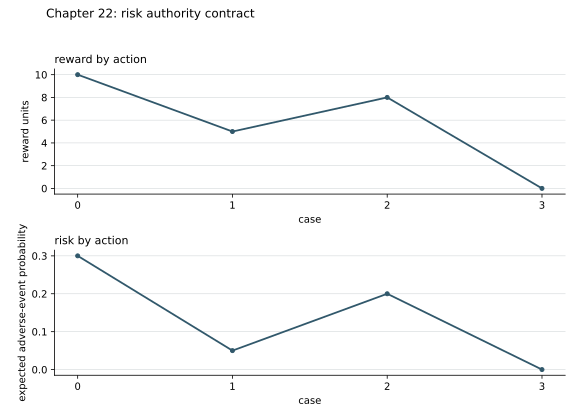

In [3]:
display(SVG(figure_svg(report)))

**Figure 22.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

A large penalty can look like a safety rule while leaving prohibited behavior available. If reward grows or the penalty is miscalibrated, the controller may choose the forbidden row. The hard authorization predicate avoids that particular tradeoff by removing the action before optimization.

Risk estimates also carry uncertainty. A supplied value 0.05 is not evidence of a bound unless an evaluation or formal process supports it. This notebook does not add confidence limits to supplied probabilities. When a limit must be conservative, provide a justified upper estimate or use a separate measurement design.

Pathwise properties need another representation. A mean-risk constraint cannot ensure that every trajectory respects a temporal invariant or that a tool never receives an unauthorized command. Use an explicit monitor and effect trace for those questions. Keep refusal and escalation alternatives visible when no permitted action meets the risk contract.

Chapter 22: risk-authority-contract
Which choices satisfy both current authority and a declared expected-risk limit?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "unconstrained_penalty_choice": "fast-release",
  "authorized_penalty_choice": "risky-authorized",
  "constrained_choice": "risky-authorized",
  "feasible_count": 3
}

Interpretation:
A finite penalty can favor a forbidden or over-limit action. Authorization filters the action set; an expected-risk constraint filters authorized alternatives again.

Assumptions:
- Risks are supplied expected probabilities for the same adverse event.
- Authorization is a current hard predicate.

Limitations:
- Expected risk does not establish pathwise safety.
- Missing feasible actions requires abstention or a new authorized alternative.

Execution: completed locally; constructed inputs are not deployment measurements.


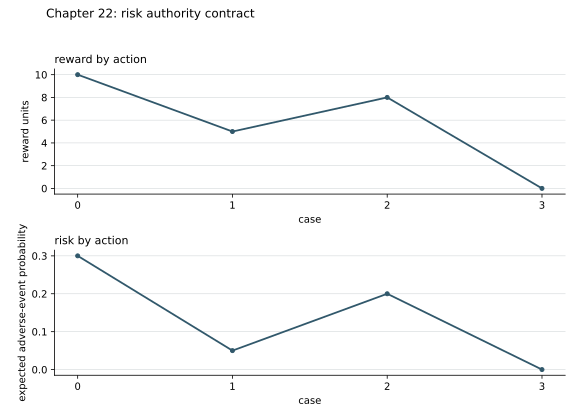

In [4]:
changed_inputs = {'risk_limit': 0.25,
 'risk_penalty': 5,
 'actions': [{'name': 'fast-release', 'reward': 10, 'risk': 0.3, 'authorized': False},
             {'name': 'reviewed-release', 'reward': 5, 'risk': 0.05, 'authorized': True},
             {'name': 'risky-authorized', 'reward': 8, 'risk': 0.2, 'authorized': True},
             {'name': 'abstain', 'reward': 0, 'risk': 0, 'authorized': True}]}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 22.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

The transfer limit is zero. Act has risk 0.01 and is therefore infeasible, even though its penalized value is 19 under penalty 100. Wait has risk 0 and reward-1, so it is the only constrained choice. Negative reward does not invalidate a feasible refusal.

When applying this to your own system, identify who owns the permission predicate and who owns the risk threshold. State the adverse event precisely and keep its probability denominator consistent across alternatives. A practical report should explain which rows fail authority, which fail expected risk, and which remain available. It should not convert a low average into a guarantee about every run.

In [5]:
transfer_inputs = {'risk_limit': 0,
 'risk_penalty': 100,
 'actions': [{'name': 'act', 'reward': 20, 'risk': 0.01, 'authorized': True},
             {'name': 'wait', 'reward': -1, 'risk': 0, 'authorized': True}]}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 22: risk-authority-contract
Which choices satisfy both current authority and a declared expected-risk limit?
Evidence: constructed transfer example

Calculated quantities:
{
  "unconstrained_penalty_choice": "act",
  "authorized_penalty_choice": "act",
  "constrained_choice": "wait",
  "feasible_count": 1
}

Interpretation:
A finite penalty can favor a forbidden or over-limit action. Authorization filters the action set; an expected-risk constraint filters authorized alternatives again.

Assumptions:
- Risks are supplied expected probabilities for the same adverse event.
- Authorization is a current hard predicate.

Limitations:
- Expected risk does not establish pathwise safety.
- Missing feasible actions requires abstention or a new authorized alternative.

Execution: completed locally; constructed inputs are not deployment measurements.


## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **risk_limit:** Maximum allowed adverse-event probability in [0,1].
- **risk_penalty:** Nonnegative utility deduction per unit probability.
- **actions:** Each row has name,reward:finite number,risk:probability,authorized:exact boolean. Abstention must be an explicit row.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch22.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 22: risk-authority-contract
Which choices satisfy both current authority and a declared expected-risk limit?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "unconstrained_penalty_choice": "act",
  "authorized_penalty_choice": "act",
  "constrained_choice": "wait",
  "feasible_count": 1
}

Interpretation:
A finite penalty can favor a forbidden or over-limit action. Authorization filters the action set; an expected-risk constraint filters authorized alternatives again.

Assumptions:
- Risks are supplied expected probabilities for the same adverse event.
- Authorization is a current hard predicate.

Limitations:
- Expected risk does not establish pathwise safety.
- Missing feasible actions requires abstention or a new authorized alternative.

Execution: completed locally; constructed inputs are not deployment measurements.


## Explore the four chapter demonstrations

The following sections reproduce every demonstration in the illustrated chapter reader. They use the same declared controls, calculation and figure. Begin with the prediction, run the worked case, change one control, then inspect the complete state table. The chapter experiment above remains available for your own compatible inputs.

In [7]:
from math_ai_agents.demos import demo_catalog, demo_states, run_demo, demo_report_text

<a id="demo-c22-d01"></a>

### Demonstration 1: A penalty hides an exchange rate

With the same two policies, when does a fixed penalty choose a policy that a cost limit would remove?

![Equation 22.2](../assets/math/e3a0e835f74db5a1ee08.svg)

![Equation 22.1](../assets/math/eb14c1e8bbd95b7a8e74.svg)

**Symbols and units:** Ret is the expected reward of a policy and Cost its expected measured cost. The multiplier lambda_safe is the exchange rate: how many reward units one cost unit is worth. d_1 is the declared cost limit. The penalty rule picks the larger blended score; the constraint rule keeps only policies with cost at most the limit, then picks the larger reward. The chapter's table has Careful at reward 8 and cost 0.5, Aggressive at 12 and 1.5, limit 1. Workbench VI.1 has Careful at 7 and 0.5, Aggressive at 11 and 2, limit 1. The laboratory's transfer case has act at reward 20 and cost 0.01, wait at -1 and 0, limit 0. The best mix is the largest chance of the costlier policy that keeps expected cost within the limit, if randomising once before the episode is allowed (the workbench's reading).

Each policy's score falls with the multiplier at the rate of its own cost, so the policy with more cost loses ground faster. The lines cross at the reward gap divided by the cost gap. The constraint rule never uses the multiplier: it draws a boundary in the reward-cost plane and only policies on the allowed side are eligible, as in Figure 22.2. In the transfer case the multiplier would have to exceed 2100 before the penalty rule gave up act (at 2100 the two scores tie), although act already breaks a limit of 0.

**Use in this chapter:** When a team reports that a penalty setting keeps cost down, ask whether cost is a preference with a defensible exchange rate or a limit. If it is a limit, state it as a limit and check each policy against it.

**Assumptions:** One step, two policies, one cost, and expected values read as the whole story. Each flip point belongs to its two policies and reward scale, not to any other problem. Mixing assumes the choice of policy is made once before the episode so rewards and costs mix linearly; it does not make a forbidden action permitted. Even the constrained choice says nothing about a single bad episode or a hazard the cost leaves out.

**Predict before running:** In the chapter's table with limit 1, raise the multiplier through 2, 4 and 6. What does the penalty rule do, and does the constraint rule ever switch?

**Controls you can change:**

- **Policies and limit:** `case` accepts 'table', 'workbench', 'transfer'.
- **Penalty multiplier:** `penalty` accepts 2, 4, 6, 100.

**Source section:** Fixed penalties make a hidden exchange rate.

**Evidence:** constructed teaching example.

Constructed example: the chapter's own two-policy table, Mathematical Workbench problem VI.1 (Careful 7 and 0.5, Aggressive 11 and 2) and the laboratory's transfer case (act and wait, limit 0, multiplier 100). The transfer case is also evaluated with the laboratory's risk and authority function; the other two have costs above 1 and are computed directly.

Prediction choices:

1. The penalty rule picks Aggressive at 2, ties at 4 and picks Careful at 6; the constraint rule always picks Careful
2. The penalty rule picks Careful at every multiplier
3. The penalty rule picks Aggressive at every multiplier, so it always agrees with the constraint rule

**Common wrong turn:** The chapter warns against presenting a fixed penalty as a satisfaction guarantee for a limit it was never designed to enforce. In the transfer case at multiplier 100 the penalty rule still picks act: 20 - 100 x 0.01 = 19.00 beats -1.00, although act's cost 0.01 breaks the limit 0.

A penalty hides an exchange rate
Controls: {"case": "table", "penalty": 2}
Evidence: constructed teaching example

Calculated quantities:
Careful score: 7.00
Aggressive score: 9.00
Penalty rule picks: Aggressive
Policies within the limit: Careful
Constraint rule picks: Careful
Multiplier at which the penalty rule flips: 4
Best randomised mix: workbench reading, outside the policy family: probability 1/2 of Aggressive, reward 10.00

Worked steps:
1. Score of Careful: 8 - 2 x 0.5 = 7.00.
2. Score of Aggressive: 12 - 2 x 1.5 = 9.00.
3. Penalty rule: Aggressive has the larger score.
4. Flip multiplier = (12 - 8) / (1.5 - 0.5) = 4 / 1 = 4.
5. Limit d = 1: policies with cost at most d are Careful.
6. Constraint rule: Careful.

Careful: 8 - 2 x 0.5 = 7.00; Aggressive: 12 - 2 x 1.5 = 9.00. The penalty rule picks Aggressive; the flip point is (12 - 8) / (1.5 - 0.5) = 4 / 1 = 4, and a multiplier above it favors Careful. Aggressive costs 1.5, above the limit 1, so it is removed whatever it earns;

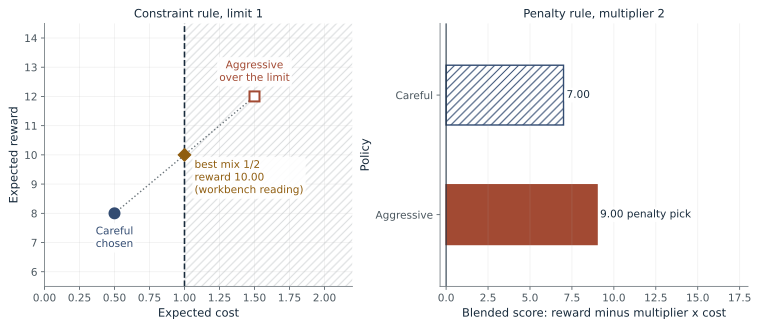

In [8]:
demo_id = 'C22-D01'
demo_controls = {'case': 'table', 'penalty': 2}
demo_result = run_demo(22, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Policies and limit** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

A penalty hides an exchange rate
Controls: {"case": "workbench", "penalty": 2}
Evidence: constructed teaching example

Calculated quantities:
Careful score: 6.00
Aggressive score: 7.00
Penalty rule picks: Aggressive
Policies within the limit: Careful
Constraint rule picks: Careful
Multiplier at which the penalty rule flips: 2.67
Best randomised mix: probability 1/3 of Aggressive, reward 8.33

Worked steps:
1. Score of Careful: 7 - 2 x 0.5 = 6.00.
2. Score of Aggressive: 11 - 2 x 2 = 7.00.
3. Penalty rule: Aggressive has the larger score.
4. Flip multiplier = (11 - 7) / (2 - 0.5) = 4 / 1.5 = 2.67.
5. Limit d = 1: policies with cost at most d are Careful.
6. Constraint rule: Careful.

Careful: 7 - 2 x 0.5 = 6.00; Aggressive: 11 - 2 x 2 = 7.00. The penalty rule picks Aggressive; the flip point is (11 - 7) / (2 - 0.5) = 4 / 1.5 = 2.67, and a multiplier above it favors Careful. Aggressive costs 2, above the limit 1, so it is removed whatever it earns; the constraint rule picks Careful. If r

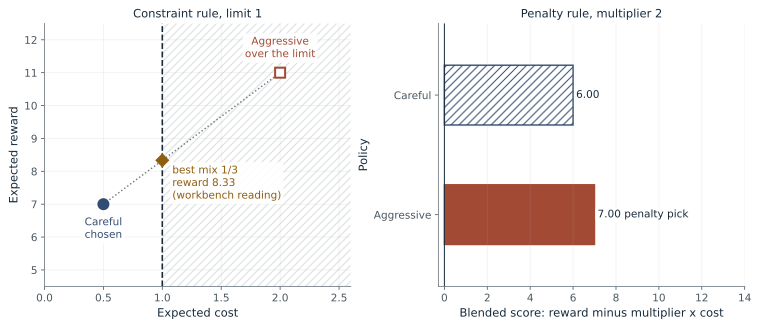

In [9]:
changed_controls = {'case': 'workbench', 'penalty': 2}
changed_demo = run_demo(22, 'C22-D01', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [10]:
state_rows = []
for controls in demo_states(22, 'C22-D01'):
    state = run_demo(22, 'C22-D01', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "case": "table",
      "penalty": 2
    },
    "metrics": [
      [
        "Careful score",
        "7.00"
      ],
      [
        "Aggressive score",
        "9.00"
      ],
      [
        "Penalty rule picks",
        "Aggressive"
      ],
      [
        "Policies within the limit",
        "Careful"
      ],
      [
        "Constraint rule picks",
        "Careful"
      ],
      [
        "Multiplier at which the penalty rule flips",
        "4"
      ],
      [
        "Best randomised mix",
        "workbench reading, outside the policy family: probability 1/2 of Aggressive, reward 10.00"
      ]
    ]
  },
  {
    "controls": {
      "case": "table",
      "penalty": 4
    },
    "metrics": [
      [
        "Careful score",
        "6.00"
      ],
      [
        "Aggressive score",
        "6.00"
      ],
      [
        "Penalty rule picks",
        "tie (Careful and Aggressive)"
      ],
      [
        "Policies within the limit",
        

**Check your understanding:** Work this one by hand (3 is not an offered multiplier). In workbench VI.1 with the limit at 1 and the multiplier at 3, which policy does the penalty rule pick, and which does the constraint rule pick?

[Answer and worked reasoning](../solutions/ch22.md#demonstration-1). [Matching browser demonstration](../readers/22-risk-authority-contract/reader.html#C22-D01).

<a id="demo-c22-d02"></a>

### Demonstration 2: A bound permits excess, so leave a margin

How much can the modeled cost exceed the limit after one update, how large a step does a margin allow, and when does the margin cover it?

![Equation 22.3](../assets/math/371c8675bdb06b88d9bb.svg)

![Equation 22.4](../assets/math/23fd856a63c4e5644b78.svg)

**Symbols and units:** d is the cost limit (10 here). delta is the step-size parameter of one update, the trust-region size measured by a KL-divergence condition. gamma is the discount factor. epsilon is the largest absolute expected constraint advantage over states (0.1 here). The fraction after d is the allowance, the most the bound lets the cost return rise above d. The margin, written epsilon_safe in the chapter, is room reserved below d (0.5 or 1.0 here), so the optimizer aims at the ceiling d minus margin.

The allowance is sqrt(2 delta) times gamma times epsilon, divided by (1 - gamma) squared. A larger trust region lets the update treat its local picture as informative farther away, which raises the allowance in proportion to the square root of the step, and a discount nearer 1 blows it up through the squared denominator. The margin is a separate choice: it only helps when it is at least as large as the allowance, and the right-hand curve shows the largest step it covers.

**Use in this chapter:** Before citing the proposition to justify a safety margin, compute the allowance for your own step size, discount and advantage, and set the margin from that number rather than from habit.

**Assumptions:** The bound concerns one ideal update inside the modeled problem; it is not a statement about a training run, a sampled update or a changed deployment. The values here are constructed. The lower row applies the bound with the ceiling in the role of the limit (d replaced by d minus the margin), which is this reader's illustration of the margin idea. The target (what the optimizer asks for), the bound (what the theorem permits) and observed behavior (what an experiment records) are three different things; this figure shows the first two only.

**Predict before running:** At discount 0.85 and margin 0.5, will a step size of 0.005 fit inside the margin? What about 0.02?

**Controls you can change:**

- **Step size delta:** `step` accepts 0.005, 0.02.
- **Discount factor gamma:** `discount` accepts 0.5, 0.85, 0.9.
- **Safety margin:** `margin` accepts 0.5, 1.0.

**Source section:** A constraint is not a promise.

**Evidence:** constructed teaching example.

Constructed example: the chapter's bound evaluated with values defined for this reader (limit 10, advantage 0.1, margins 0.5 and 1.0).

Prediction choices:

1. Both fit inside the margin
2. 0.005 fits (allowance 0.378) and 0.02 does not (0.756)
3. Neither fits

**Boundary of the conclusion:** CPO's one-update result does not prove that a whole training run, or an altered deployment, satisfies a constraint. A clear optimization claim can grant limited authority only within the threat model, measurement, margin and update assumptions that make it true.

**Common wrong turn:** Proposition 2 gives a bound on how far above the limit the new cost return may be, not a promise that it is below the limit. The right side of Equation (22.3) is d plus a nonnegative allowance, so aiming at the limit leaves room for a modeled overshoot whenever the allowance is positive.

A bound permits excess, so leave a margin
Controls: {"step": 0.005, "discount": 0.85, "margin": 0.5}
Evidence: constructed teaching example

Calculated quantities:
Allowance above the aimed level: 0.378
Worst case when aiming at the limit: 10.378
Ceiling d minus margin: 9.5
Worst case when aiming at the ceiling: 9.878
Margin covers the allowance: yes
Largest step the margin covers: 0.0088

Worked steps:
1. Root: sqrt(2 x 0.005) = 0.100.
2. Allowance = 0.100 x 0.85 x 0.1 / 0.0225 = 0.378.
3. Aim at the limit: 10.0 + 0.378 = 10.378.
4. Ceiling = 10.0 - 0.5 = 9.5; worst case 9.5 + 0.378 = 9.878.
5. Margin 0.5 against allowance 0.378: covered.
6. Largest covered step = 0.0088.

Allowance = sqrt(2 x 0.005) x 0.85 x 0.1 / (1 - 0.85)^2 = 0.10 x 0.85 x 0.1 / 0.0225 = 0.378. Aiming at the limit: 10.0 + 0.378 = 10.378. Aiming at the ceiling, which means the bound is applied with the ceiling in place of d: 9.5 + 0.378 = 9.878. The allowance is below the margin 0.5, so the modeled worst case stays

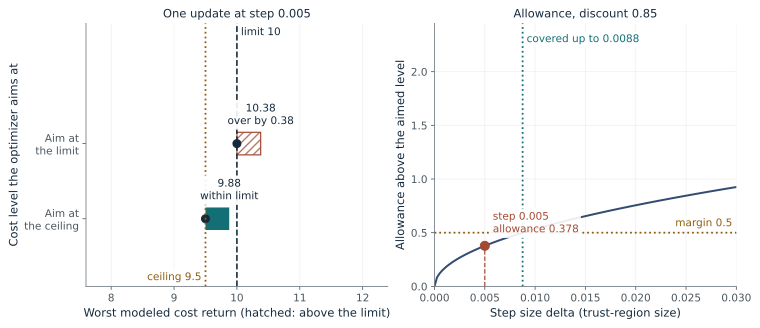

In [11]:
demo_id = 'C22-D02'
demo_controls = {'step': 0.005, 'discount': 0.85, 'margin': 0.5}
demo_result = run_demo(22, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Step size delta** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

A bound permits excess, so leave a margin
Controls: {"step": 0.02, "discount": 0.85, "margin": 0.5}
Evidence: constructed teaching example

Calculated quantities:
Allowance above the aimed level: 0.756
Worst case when aiming at the limit: 10.756
Ceiling d minus margin: 9.5
Worst case when aiming at the ceiling: 10.256
Margin covers the allowance: no
Largest step the margin covers: 0.0088

Worked steps:
1. Root: sqrt(2 x 0.02) = 0.200.
2. Allowance = 0.200 x 0.85 x 0.1 / 0.0225 = 0.756.
3. Aim at the limit: 10.0 + 0.756 = 10.756.
4. Ceiling = 10.0 - 0.5 = 9.5; worst case 9.5 + 0.756 = 10.256.
5. Margin 0.5 against allowance 0.756: not covered.
6. Largest covered step = 0.0088.

Allowance = sqrt(2 x 0.02) x 0.85 x 0.1 / (1 - 0.85)^2 = 0.20 x 0.85 x 0.1 / 0.0225 = 0.756. Aiming at the limit: 10.0 + 0.756 = 10.756. Aiming at the ceiling, which means the bound is applied with the ceiling in place of d: 9.5 + 0.756 = 10.256. The allowance is above the margin 0.5, so even aiming at the ceilin

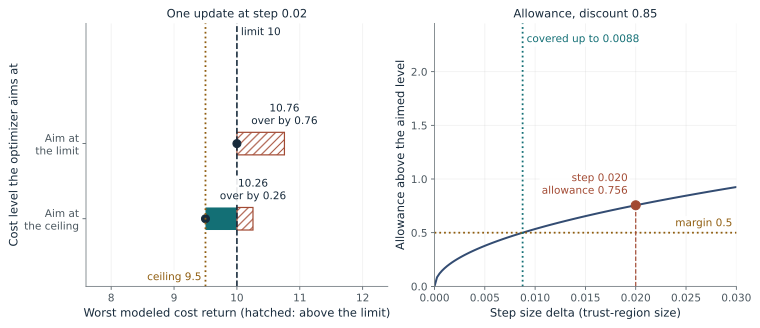

In [12]:
changed_controls = {'step': 0.02, 'discount': 0.85, 'margin': 0.5}
changed_demo = run_demo(22, 'C22-D02', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [13]:
state_rows = []
for controls in demo_states(22, 'C22-D02'):
    state = run_demo(22, 'C22-D02', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "step": 0.005,
      "discount": 0.5,
      "margin": 0.5
    },
    "metrics": [
      [
        "Allowance above the aimed level",
        "0.020"
      ],
      [
        "Worst case when aiming at the limit",
        "10.020"
      ],
      [
        "Ceiling d minus margin",
        "9.5"
      ],
      [
        "Worst case when aiming at the ceiling",
        "9.520"
      ],
      [
        "Margin covers the allowance",
        "yes"
      ],
      [
        "Largest step the margin covers",
        "3.1250"
      ]
    ]
  },
  {
    "controls": {
      "step": 0.005,
      "discount": 0.5,
      "margin": 1.0
    },
    "metrics": [
      [
        "Allowance above the aimed level",
        "0.020"
      ],
      [
        "Worst case when aiming at the limit",
        "10.020"
      ],
      [
        "Ceiling d minus margin",
        "9.0"
      ],
      [
        "Worst case when aiming at the ceiling",
        "9.020"
      ],
      [
      

**Check your understanding:** Work this one by hand, using the control for the margin. With step size 0.005, discount 0.9 and advantage 0.1, what is the allowance, and does a margin of 0.5 cover it? What about a margin of 1.0?

[Answer and worked reasoning](../solutions/ch22.md#demonstration-2). [Matching browser demonstration](../readers/22-risk-authority-contract/reader.html#C22-D02).

<a id="demo-c22-d03"></a>

### Demonstration 3: Two other risk contracts: a tail and a budget

For a rare bad episode, how far apart are mean cost and tail severity, and how does a risk budget shrink as charged actions spend it?

![Equation 22.5](../assets/math/efc01bbeb46ffdf27496.svg)

![Equation 22.6](../assets/math/e765c8011cb6df6a9d96.svg)

**Symbols and units:** C is the cost of one episode: 100 with probability 0.01, otherwise 0 (the chapter's lottery). alpha sets the tail: the worst share 1 - alpha of episodes. z is a cutoff, and (C - z)+ is the amount by which C exceeds z, or 0. CVaR is the smallest value the bracket takes as z varies, which equals the average cost over the worst 1 - alpha share. In the budget, B is the stated cumulative risk budget, b_t what remains before decision t, and r-hat the declared conservative charge of the chosen action; the four charges 0.04, 0.05, 0.03 and 0.05 are values defined for the reader, and a refused action is replaced by a fallback that charges 0.

For this lottery the bracket is a bent line in z, so its smallest value sits at z = 0 or z = 100. At z = 0 it equals the mean divided by the tail share; at z = 100 it equals 100. CVaR is the smaller of the two, so a tail wider than the bad episode dilutes it with zeros. The budget is a different contract: it is an accounting state that falls by each charge, and a charge larger than what remains cannot be taken, even when a smaller one proposed later still fits.

**Use in this chapter:** If one rare, severe episode is the worry, a limit on mean cost can look small while the tail measure is large. State which one the limit is about, and why. For a bounded horizon, keep a running budget and refuse a charged action that exceeds what remains.

**Assumptions:** A single two-outcome lottery and four charges defined for the reader. CVaR asks for average severity in a declared upper tail, not a promise that no episode is bad. The budget rule prevents one action from exceeding the remaining authority; it does not prove the charges are calibrated, independent, complete or safe beyond the declared horizon.

**Predict before running:** For a bad episode with probability 0.01, is the tail average larger at alpha 0.9 or at alpha 0.99?

**Controls you can change:**

- **Tail level alpha:** `alpha` accepts 0.9, 0.95, 0.99, 0.995.
- **Risk budget B:** `budget` accepts 0.05, 0.1, 0.2.

**Source section:** Other risk contracts.

**Evidence:** constructed teaching example.

Constructed example: the chapter's lottery (cost 100 with probability 0.01, else 0) with other tail levels, and a four-decision budget whose charges are defined for this reader.

Prediction choices:

1. Larger at alpha 0.9
2. Larger at alpha 0.99 (100 against 10)
3. The same at both

**Boundary of the conclusion:** Expected auxiliary-cost constraints are not sufficient for every safety problem: a rare catastrophic outcome, a distribution shift, an unobserved state, a human authorization boundary or an adversarial interaction may require a different risk measure, monitoring system, physical safeguard or refusal rule.

**Common wrong turn:** The chapter says CVaR asks for average severity in a declared upper tail, not a promise that no episode is bad, and that none of the measures covers a hazard the cost variable omits. Here CVaR is 100 at alpha 0.99, yet the worst episode still happens with probability 0.01.

Two other risk contracts: a tail and a budget
Controls: {"alpha": 0.99, "budget": 0.1}
Evidence: constructed teaching example

Calculated quantities:
Mean cost: 1.0
Tail share 1 minus alpha: 0.01
Tail average (CVaR): 100.0
Budget B: 0.10
Charges accepted: 2 of 4
Budget left at the end: 0.01

Worked steps:
1. Mean cost = 0.01 x 100 = 1.0; tail share = 0.01.
2. Cutoff z = 0 gives 1.0 / 0.01 = 100.0; z = 100 gives 100.0.
3. CVaR is the smaller corner: 100.0.
4. Budget t = 1: 0.04 <= 0.10, charged, b = 0.10 - 0.04 = 0.06.
5. Budget t = 2: 0.05 <= 0.06, charged, b = 0.06 - 0.05 = 0.01.
6. Budget t = 3: 0.03 > 0.01, refused, b stays 0.01.
7. Budget t = 4: 0.05 > 0.01, refused, b stays 0.01.
8. Left at the end: 0.01.

Mean cost = 0.01 x 100 + 0.99 x 0 = 1.0. Tail share = 1 - 0.99 = 0.01. Objective at z = 0: 0 + 1.0 / 0.01 = 100.0; at z = 100: 100 + 0 / 0.01 = 100.0. Both corners give 100.0, so the minimum is flat and CVaR is 100.0: the tail is exactly the bad episode. The curve rises above th

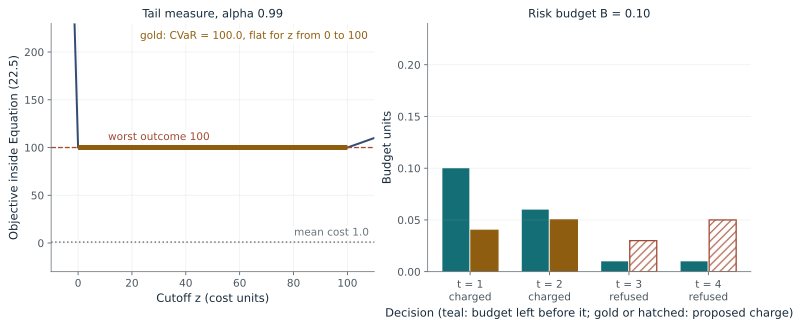

In [14]:
demo_id = 'C22-D03'
demo_controls = {'alpha': 0.99, 'budget': 0.1}
demo_result = run_demo(22, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Tail level alpha** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

Two other risk contracts: a tail and a budget
Controls: {"alpha": 0.9, "budget": 0.1}
Evidence: constructed teaching example

Calculated quantities:
Mean cost: 1.0
Tail share 1 minus alpha: 0.1
Tail average (CVaR): 10.0
Budget B: 0.10
Charges accepted: 2 of 4
Budget left at the end: 0.01

Worked steps:
1. Mean cost = 0.01 x 100 = 1.0; tail share = 0.1.
2. Cutoff z = 0 gives 1.0 / 0.1 = 10.0; z = 100 gives 100.0.
3. CVaR is the smaller corner: 10.0.
4. Budget t = 1: 0.04 <= 0.10, charged, b = 0.10 - 0.04 = 0.06.
5. Budget t = 2: 0.05 <= 0.06, charged, b = 0.06 - 0.05 = 0.01.
6. Budget t = 3: 0.03 > 0.01, refused, b stays 0.01.
7. Budget t = 4: 0.05 > 0.01, refused, b stays 0.01.
8. Left at the end: 0.01.

Mean cost = 0.01 x 100 + 0.99 x 0 = 1.0. Tail share = 1 - 0.9 = 0.1. Objective at z = 0: 0 + 1.0 / 0.1 = 10.0; at z = 100: 100 + 0 / 0.1 = 100.0. The smaller corner is z = 0 with 10.0, so CVaR is 10.0: the tail (0.1) is wider than the bad episode (0.01), so zeros dilute the average. Th

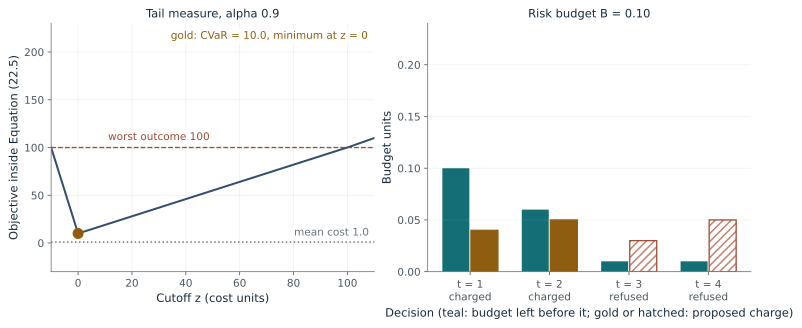

In [15]:
changed_controls = {'alpha': 0.9, 'budget': 0.1}
changed_demo = run_demo(22, 'C22-D03', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [16]:
state_rows = []
for controls in demo_states(22, 'C22-D03'):
    state = run_demo(22, 'C22-D03', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "alpha": 0.9,
      "budget": 0.05
    },
    "metrics": [
      [
        "Mean cost",
        "1.0"
      ],
      [
        "Tail share 1 minus alpha",
        "0.1"
      ],
      [
        "Tail average (CVaR)",
        "10.0"
      ],
      [
        "Budget B",
        "0.05"
      ],
      [
        "Charges accepted",
        "1 of 4"
      ],
      [
        "Budget left at the end",
        "0.01"
      ]
    ]
  },
  {
    "controls": {
      "alpha": 0.9,
      "budget": 0.1
    },
    "metrics": [
      [
        "Mean cost",
        "1.0"
      ],
      [
        "Tail share 1 minus alpha",
        "0.1"
      ],
      [
        "Tail average (CVaR)",
        "10.0"
      ],
      [
        "Budget B",
        "0.10"
      ],
      [
        "Charges accepted",
        "2 of 4"
      ],
      [
        "Budget left at the end",
        "0.01"
      ]
    ]
  },
  {
    "controls": {
      "alpha": 0.9,
      "budget": 0.2
    },
    "metrics

**Check your understanding:** Work this one by hand (a budget of 0.08 is not offered). With budget 0.08 and the charges 0.04, 0.05, 0.03, 0.05 proposed in order, which are charged and what is left? And a bad episode costs 100 with probability 0.02: what is CVaR at alpha 0.97?

[Answer and worked reasoning](../solutions/ch22.md#demonstration-3). [Matching browser demonstration](../readers/22-risk-authority-contract/reader.html#C22-D03).

<a id="demo-c22-d04"></a>

### Demonstration 4: Authority first, risk limit second, reward last

Which actions may be considered at all, which of those has the best reward, and what happens when one route to the actuator skips the check?

![Equation 22.1](../assets/math/eb14c1e8bbd95b7a8e74.svg)

![Equation 22.2](../assets/math/e3a0e835f74db5a1ee08.svg)

**Symbols and units:** Each action has a reward, an expected adverse-event probability (risk) and a yes or no current permission. The risk limit is the largest probability allowed. The penalty is the reward deducted per unit of risk. The gate keeps only actions that are authorized and within the risk limit; the gate pick is the highest reward among those. In the displayed equations, Ret is the reward, Cost is the risk, d_i is the risk limit and lambda_safe is the penalty, with each action standing in for a policy pi. Authority, the yes or no permission, is an extra condition that the equations do not show. A bypass is a route to the actuator that does not pass the check.

The penalty rule scores every row by reward minus penalty times risk, so a high-reward forbidden row can win. The gate removes rows before any score is used: authority is a yes or no condition, so no limit or penalty setting grants it. A looser risk limit can bring back an over-limit row but never a forbidden one. A gate only constrains routes that pass through it: with a bypass, the check exists but the unauthorized row can still run.

**Use in this chapter:** For an agent that can call tools, list each action with its permission and risk, remove what is not permitted, then rank the rest. Keep an explicit abstain row, provided abstain is authorized and its risk is within the limit, so the set is never empty. Confirm that every route to the actuator passes the gate.

**Assumptions:** Rewards, risks and permissions are supplied values; nothing here estimates risk. An expected-risk limit is a statement about an average, so an action with risk 0.05 can still end badly. A large enough penalty can mimic a gate in one case and fail in the next. In the bypass states the unchecked route is assumed to run the controller's own penalty pick; that is this reader's illustration of the chapter's complete-mediation requirement.

**Predict before running:** Raise the risk limit from 0.1 to 0.25. Does fast-release become eligible? Which action does the gate now pick?

**Controls you can change:**

- **Risk limit:** `limit` accepts 0, 0.1, 0.25.
- **Penalty per unit of risk:** `penalty` accepts 5, 25.
- **Routes to the actuator:** `route` accepts 'checked', 'bypass'.

**Source section:** Authority is an operating envelope.

**Evidence:** constructed teaching example.

Constructed example: the laboratory's four-action example, evaluated with the laboratory's risk and authority function. The four rewards, risks and permissions are not taken from the chapter, whose section supports only the distinction between an objective and a gate. The bypass is defined for this reader.

Prediction choices:

1. Fast-release becomes eligible and wins
2. Risky-authorized becomes the gate pick; fast-release stays out
3. Reviewed-release stays the gate pick

**Boundary of the conclusion:** Expected auxiliary-cost constraints are not sufficient for every safety problem: a rare catastrophic outcome, a distribution shift, an unobserved state, a human authorization boundary or an adversarial interaction may require a different risk measure, monitoring system, physical safeguard or refusal rule.

**Common wrong turn:** The chapter separates a safety objective, which changes how outcomes are ranked (Equation 22.2), from a safety gate, which decides whether an action path may proceed at all. Confusion begins when a system that has only an objective is described as though it had a gate.

Authority first, risk limit second, reward last
Controls: {"limit": 0.1, "penalty": 5, "route": "checked"}
Evidence: constructed teaching example

Calculated quantities:
Penalty pick over all rows: fast-release
Penalty pick among authorized rows: risky-authorized
Gate pick (authority, then limit, then reward): reviewed-release
Eligible actions: 2 of 4
Removed by authority: fast-release
Removed by the risk limit: risky-authorized
Row that executes: reviewed-release

Worked steps:
1. Score every row: reward - penalty x risk (the sums above).
2. Penalty rule over all rows: fast-release.
3. Authority removes: fast-release.
4. Risk limit 0.1 then removes: risky-authorized.
5. Highest reward among the 2 eligible rows: reviewed-release.
6. Row that executes: reviewed-release.

fast-release: 10 - 5 x 0.3 = 8.50; reviewed-release: 5 - 5 x 0.05 = 4.75; risky-authorized: 8 - 5 x 0.2 = 7.00; abstain: 0 - 5 x 0 = 0.00. The penalty rule picks fast-release from all rows, without asking about authorit

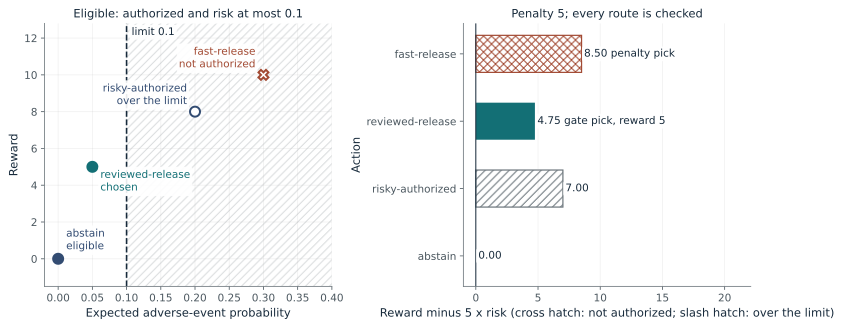

In [17]:
demo_id = 'C22-D04'
demo_controls = {'limit': 0.1, 'penalty': 5, 'route': 'checked'}
demo_result = run_demo(22, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Risk limit** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

Authority first, risk limit second, reward last
Controls: {"limit": 0, "penalty": 5, "route": "checked"}
Evidence: constructed teaching example

Calculated quantities:
Penalty pick over all rows: fast-release
Penalty pick among authorized rows: risky-authorized
Gate pick (authority, then limit, then reward): abstain
Eligible actions: 1 of 4
Removed by authority: fast-release
Removed by the risk limit: reviewed-release, risky-authorized
Row that executes: abstain

Worked steps:
1. Score every row: reward - penalty x risk (the sums above).
2. Penalty rule over all rows: fast-release.
3. Authority removes: fast-release.
4. Risk limit 0 then removes: reviewed-release, risky-authorized.
5. Highest reward among the 1 eligible rows: abstain.
6. Row that executes: abstain.

fast-release: 10 - 5 x 0.3 = 8.50; reviewed-release: 5 - 5 x 0.05 = 4.75; risky-authorized: 8 - 5 x 0.2 = 7.00; abstain: 0 - 5 x 0 = 0.00. The penalty rule picks fast-release from all rows, without asking about authority. E

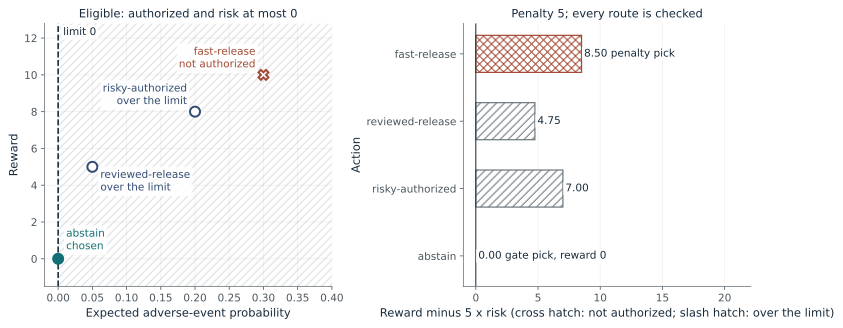

In [18]:
changed_controls = {'limit': 0, 'penalty': 5, 'route': 'checked'}
changed_demo = run_demo(22, 'C22-D04', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [19]:
state_rows = []
for controls in demo_states(22, 'C22-D04'):
    state = run_demo(22, 'C22-D04', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "limit": 0,
      "penalty": 5,
      "route": "checked"
    },
    "metrics": [
      [
        "Penalty pick over all rows",
        "fast-release"
      ],
      [
        "Penalty pick among authorized rows",
        "risky-authorized"
      ],
      [
        "Gate pick (authority, then limit, then reward)",
        "abstain"
      ],
      [
        "Eligible actions",
        "1 of 4"
      ],
      [
        "Removed by authority",
        "fast-release"
      ],
      [
        "Removed by the risk limit",
        "reviewed-release, risky-authorized"
      ],
      [
        "Row that executes",
        "abstain"
      ]
    ]
  },
  {
    "controls": {
      "limit": 0,
      "penalty": 5,
      "route": "bypass"
    },
    "metrics": [
      [
        "Penalty pick over all rows",
        "fast-release"
      ],
      [
        "Penalty pick among authorized rows",
        "risky-authorized"
      ],
      [
        "Gate pick (authority, then l

**Check your understanding:** Work this one by hand (0.2 is not an offered limit). With the risk limit at 0.2 and the penalty at 5, which action does the gate pick, and is fast-release eligible?

[Answer and worked reasoning](../solutions/ch22.md#demonstration-4). [Matching browser demonstration](../readers/22-risk-authority-contract/reader.html#C22-D04).

## Questions

1. Which default action wins the hard constraint?

2. Can risk_limit = 0.25 authorize fast-release?

3. Why does transfer choose wait despite negative reward?

Answers: [separate solutions](../solutions/ch22.md). Try the calculation before opening them.

## Summary

Reward penalties, expected-risk constraints, and hard authority are different decision rules. The notebook compares their choices explicitly and preserves every rejected alternative's reason. Relaxing risk can admit a previously over-limit action but cannot grant permission. The transfer case shows that a finite penalty can still prefer positive risk under a zero-risk contract. Use the constrained result within its declared probability model, while reserving pathwise and enforcement claims for separate evidence.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The assistant skill is [`maa-22-risk-authority-contract`](../skills/maa-22-risk-authority-contract/SKILL.md). It uses this notebook's tested computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 22.1

![Equation 22.1](../assets/math/eb14c1e8bbd95b7a8e74.svg)

Separates goal-seeking from permission: reward is maximized only among policies that meet every declared auxiliary-cost limit.

The same policy `\pi` appears in both ledgers, while each `i` names a distinct measured hazard and `d_i` names its limit.

LaTeX source, preserved for inspection:

```latex
\begin{aligned}
\text{maximize}_{\pi}\quad & \operatorname{Ret}^{\pi}\\
\text{subject to}\quad & \operatorname{Cost}_i^{\pi}\le d_i \quad \text{for every declared } i.
\end{aligned}\tag{22.1}
```

### Equation 22.2

![Equation 22.2](../assets/math/e3a0e835f74db5a1ee08.svg)

Turns one auxiliary cost into a fixed reward penalty so ordinary reward optimization can rank policies by one blended score.

`\lambda_{\mathrm{safe}}` sets a constant exchange rate between reward units and the first declared cost's units.

LaTeX source, preserved for inspection:

```latex
\operatorname{Score}_{\lambda_{\mathrm{safe}}}(\pi)
=\operatorname{Ret}^{\pi}-\lambda_{\mathrm{safe}}\operatorname{Cost}_1^{\pi}.
\tag{22.2}
```

### Equation 22.3

![Equation 22.3](../assets/math/371c8675bdb06b88d9bb.svg)

Bounds one update's modeled excess over cost limit by a term controlled by policy-step size, discounting, and constraint advantage.

The right side is `d_i` plus a nonnegative allowance, so the displayed result permits bounded violation rather than asserting satisfaction.

LaTeX source, preserved for inspection:

```latex
\operatorname{Cost}_i^{\pi_{k+1}}
\le d_i+
\frac{\sqrt{2\delta}\,\gamma\,\epsilon_i}{(1-\gamma)^2}.
\tag{22.3}
```

### Equation 22.4

![Equation 22.4](../assets/math/23fd856a63c4e5644b78.svg)

Reserves room below a deployment cost limit for known modeling, approximation, sampling, and update-bound exposure.

Optimization targets a stricter internal ceiling, leaving `\varepsilon_{\mathrm{safe}}` between measured planning cost and external limit `d_i`.

LaTeX source, preserved for inspection:

```latex
\operatorname{Cost}_i^{\pi}
\le d_i-\varepsilon_{\mathrm{safe}},
\qquad \varepsilon_{\mathrm{safe}}>0.
\tag{22.4}
```

### Equation 22.5

![Equation 22.5](../assets/math/efc01bbeb46ffdf27496.svg)

Replaces a mean-cost target with a declared upper-tail severity measure for episode cost `C`.

The threshold `z` searches tail cutoffs, while `1/(1-\alpha)` scales severity beyond each cutoff.

LaTeX source, preserved for inspection:

```latex
\operatorname{CVaR}_{\alpha}(C)
= \inf_{z\in\mathbb R}\left[z+\frac{1}{1-\alpha}\,\mathbb E[(C-z)_+]\right].
\tag{22.5}
```

### Equation 22.6

![Equation 22.6](../assets/math/e765c8011cb6df6a9d96.svg)

Carries a declared finite-horizon risk budget forward, preventing one charged action from spending more authority than remains.

`b_t` is an accounting state, while `\widehat r_t(a_t)` needs its own calibration and threat-model evidence.

LaTeX source, preserved for inspection:

```latex
b_{t+1}=b_t-\widehat r_t(a_t),\qquad b_0=B,\qquad \widehat r_t(a_t)\le b_t.
\tag{22.6}
```